Nom : Khadijetou Mohamed abe

Filière : GLCC

# 1. CODE SCRATCH 

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def relu(z):
    # """
    # Fonction d'activation ReLU pour la couche cachée.
    # Elle retourne z si z est positif, sinon elle retourne 0.
    # """
    # np.maximum compare chaque élément de z avec 0 et conserve le plus grand
    return np.maximum(0, z)


def relu_deriv(z):
    # """
    # Dérivée de la fonction ReLU pour la rétropropagation.
    # Elle vaut 1 pour les entrées positives, et 0 pour les entrées négatives.
    # """
    # (z > 0) produit un tableau de booléens (True/False)
    # .astype(float) transforme True en 1.0 et False en 0.0
    return (z > 0).astype(float)


def sigmoid(z):
    # """
    # Fonction d'activation Sigmoïde pour la couche 2.
    # """
    return 1 / (1 + np.exp(-z))


def sigmoid_deriv(a):
    # """
    # Dérivée de la fonction Sigmoïde calculée directement à partir de sa sortie 'a'.
    # Formule mathématique : f'(z) = f(z) * (1 - f(z))
    # """
    return a * (1 - a)


def descente_gradient_mlp(X, y, n_caches=4, pas=0.1, epochs=10000):
    # """
    # Descente de Gradient.
    # la fonction qui gère l'initialisation, la boucle d'apprentissage et la mise à jour des paramètres.
    # """
    # Récupération du nombre d'exemples d'apprentissage (m = 100)
    m = X.shape[0]
    # Nombre de caractéristiques en entrée (n = 2)
    n_entrees = X.shape[1]
    # Nombre de neurones en sortie
    n_sorties = y.shape[1]
    
    np.random.seed(42)
    
    #INITIALISATION DES PARAMÈTRES (W et b)
    # W1, b1 de la couche cachée
    W1 = np.random.randn(n_entrees, n_caches) * 0.1
    b1 = np.zeros((1, n_caches))
    # W2, b2  de la couche de sortie
    W2 = np.random.randn(n_caches, n_sorties) * 0.1
    b2 = np.zeros((1, n_sorties))
    

    for epoch in range(epochs):
        
        # 1. PROPAGATION VERS L'AVANT (FORWARD)
        # Calcul de la combinaison linéaire pour la couche cachée
        # Produit matriciel entre X (m, 2) et W1 (2, 4) auquel on ajoute le biais b1 (1, 4)
        Z1 = np.dot(X, W1) + b1
        # Application de la fonction d'activation ReLU sur la couche cachée
        # A1 est de taille (m, 4)
        A1 = relu(Z1)
        
        # Calcul de la combinaison linéaire pour la couche de sortie
        # Produit matriciel entre A1 (m, 4) et W2 (4, 1) auquel on ajoute le biais b2 (1, 1)
        Z2 = np.dot(A1, W2) + b2
        # Application de la fonction d'activation Sigmoïde pour la prédiction finale
        # A2 est de taille (m, 1)
        A2 = sigmoid(Z2)
        
        # 2. CALCUL DU COÛT (LOG-LOSS)
        # Calcul de la perte d'entropie croisée binaire pour suivre la convergence
        # L'ajout de 10**-15 prévient les erreurs log(0)
        cout = - (1 / m) * np.sum(y * np.log(A2 + 1e-15) + (1 - y) * np.log(1 - A2 + 10**-15))
        
        # 3. PROPAGATION VERS L'ARRIÈRE (BACKWARD)
        # dZ2 est le gradient de l'erreur par rapport à l'entrée de la couche de sortie (A2 - y)
        # Sa taille est de (m, 1)
        dZ2 = A2 - y
        # dW2 est le gradient calculé pour les poids W2 : (1/m) * A1.T . dZ2
        # Sa taille est de (4, 1)
        dW2 = (1 / m) * np.dot(A1.T, dZ2)
        # db2 est le gradient calculé pour le biais b2, sommé sur toutes les lignes
        # Sa taille est de (1, 1)
        db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)
        
        # Propagation de l'erreur de la couche de sortie vers la couche cachée
        # Produit matriciel de dZ2 (m, 1) et de la transposée de W2 (1, 4)
        dA1 = np.dot(dZ2, W2.T)
        # dZ1 applique la dérivée de la ReLU sur l'erreur propagée
        # Multiplication élément par élément entre dA1 (m, 4) et relu_deriv(Z1) (m, 4)
        dZ1 = dA1 * relu_deriv(Z1)
        # dW1 est le gradient calculé pour les poids W1 : (1/m) * X.T . dZ1
        # Sa taille est de (2, 4)
        dW1 = (1 / m) * np.dot(X.T, dZ1)
        # db1 est le gradient calculé pour le biais b1, sommé sur toutes les lignes
        # Sa taille est de (1, 4)
        db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)
        
        # 4. ÉTAPE DE MISE À JOUR DE LA DESCENTE DE GRADIENT (DG)
        W1 = W1 - pas * dW1
        b1 = b1 - pas * db1
        W2 = W2 - pas * dW2
        b2 = b2 - pas * db2
        
        # Affichage du coût tous les 1000 cycles d'entraînement pour valider la descente
        if epoch % 1000 == 0:
            print(f"Époque {epoch} | Coût de la Descente de Gradient : {cout:.5f}")
            
    # On retourne les paramètres finaux entraînés sous forme de dictionnaire structuré
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


def predict_scratch(X, parametres):
    # """
    # Calcule les prédictions d'un échantillon X à partir des poids et biais trouvés par la DG.
    # """
    # Calcul de la première couche linéaire
    Z1 = np.dot(X, parametres["W1"]) + parametres["b1"]
    # Passage dans la fonction ReLU
    A1 = relu(Z1)
    # Calcul de la deuxième couche linéaire
    Z2 = np.dot(A1, parametres["W2"]) + parametres["b2"]
    # Passage dans la fonction Sigmoïde
    A2 = sigmoid(Z2)
    # Seuil à 0.5 : retourne 1 si la probabilité >= 0.5, sinon 0
    return (A2 >= 0.5).astype(int)






## a. DATASET

In [5]:
# Génération des entrées binaires du problème logique du XOR
X_base = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
# Génération des sorties binaires correspondantes (0 si identiques, 1 si différents)
y_base = np.array([[0], [1], [1], [0]], dtype=np.float32)

# Duplication pour obtenir un échantillon de 100 données (25 répétitions de la base de 4 points)
# Le modèle surrapprend (overfitting) avec seulement 4 points du XOR, 
# pour cela on utilise 100 points bruités afin d’éviter le surapprentissage 
# et de l’obliger à généraliser au lieu de s’adapter exactement aux données.
X_raw = np.tile(X_base, (25, 1))
y_data = np.tile(y_base, (25, 1))

# Ajout d'un bruit 
np.random.seed(42)
bruit = np.random.normal(0, 0.08, X_raw.shape)
X_data = X_raw + bruit


## b. Exécution du code scratch

In [8]:
# Entraînement de notre modèle scratch à l'aide de notre fonction de DG
parametres_appris = descente_gradient_mlp(X_data, y_data, n_caches=4, pas=0.1, epochs=10000)

# Prédiction finale du modèle scratch sur les données d'entraînement
predictions_scratch = predict_scratch(X_data, parametres_appris)


--- Début de la Descente de Gradient Scratch ---
Époque 0 | Coût de la Descente de Gradient : 0.69324
Époque 1000 | Coût de la Descente de Gradient : 0.48005
Époque 2000 | Coût de la Descente de Gradient : 0.04967
Époque 3000 | Coût de la Descente de Gradient : 0.01942
Époque 4000 | Coût de la Descente de Gradient : 0.01149
Époque 5000 | Coût de la Descente de Gradient : 0.00802
Époque 6000 | Coût de la Descente de Gradient : 0.00611
Époque 7000 | Coût de la Descente de Gradient : 0.00491
Époque 8000 | Coût de la Descente de Gradient : 0.00409
Époque 9000 | Coût de la Descente de Gradient : 0.00350


## c. Code sklearn

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD

# Initialisation du conteneur Keras pour notre réseau séquentiel
modele_keras = Sequential()

# Ajout de la couche cachée dense avec 4 neurones et activation 'relu'
modele_keras.add(Dense(units=4, input_dim=2, activation='relu', kernel_initializer='random_normal'))

# Ajout de la couche de sortie dense avec 1 neurone et activation 'sigmoid'
modele_keras.add(Dense(units=1, activation='sigmoid', kernel_initializer='random_normal'))

# Compilation du modèle Keras en associant l'entropie croisée et l'optimiseur SGD (Descente de Gradient stochastique)
modele_keras.compile(optimizer=SGD(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])

# Lancement de la boucle d'apprentissage
modele_keras.fit(X_data, y_data, epochs=2000, batch_size=len(X_data), verbose=0)

# Extraction des prédictions binaires à l'aide d'un seuil de décision de 0.5
predictions_keras = (modele_keras.predict(X_data) >= 0.5).astype(int)

## d. Comparaison et graphiques (scratch/keras)

COMPARAISON DES PARAMÈTRES APPRIS (SCRATCH VS KERAS)

--- COUCHE CACHÉE : POIDS (W1) et BIAIS (b1) ---
W1 , b1 Scratch :
[ [[ 3.25089469 -0.01383324  2.97832441  3.04489688]
 [ 3.15670013 -0.0231475   2.9362443   3.00186154]] , [[-3.01738319e-01 -2.90465074e-03 -2.98541157e+00 -3.05215839e+00]] ]
W1 , b1 Keras:
[ [[-2.1244702  2.4148026  0.5807589  1.6805766]
 [-2.4240427  1.0805743 -0.6861265 -1.964335 ]] , [ 1.9958196  -1.2335263   0.07232947  0.1920423 ] ]

--- COUCHE CACHÉE : POIDS (W2) et BIAIS (b2) ---
W2 , b2 Scratch :
[ [[ 4.54128044  0.05421731 -5.13591521 -5.25083963]] , [[-5.1520085]] ]
W2 , b2 Keras:
[ [[-3.7908826 -2.9185717  0.9019665  2.593298 ]] , [2.515361] ]
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


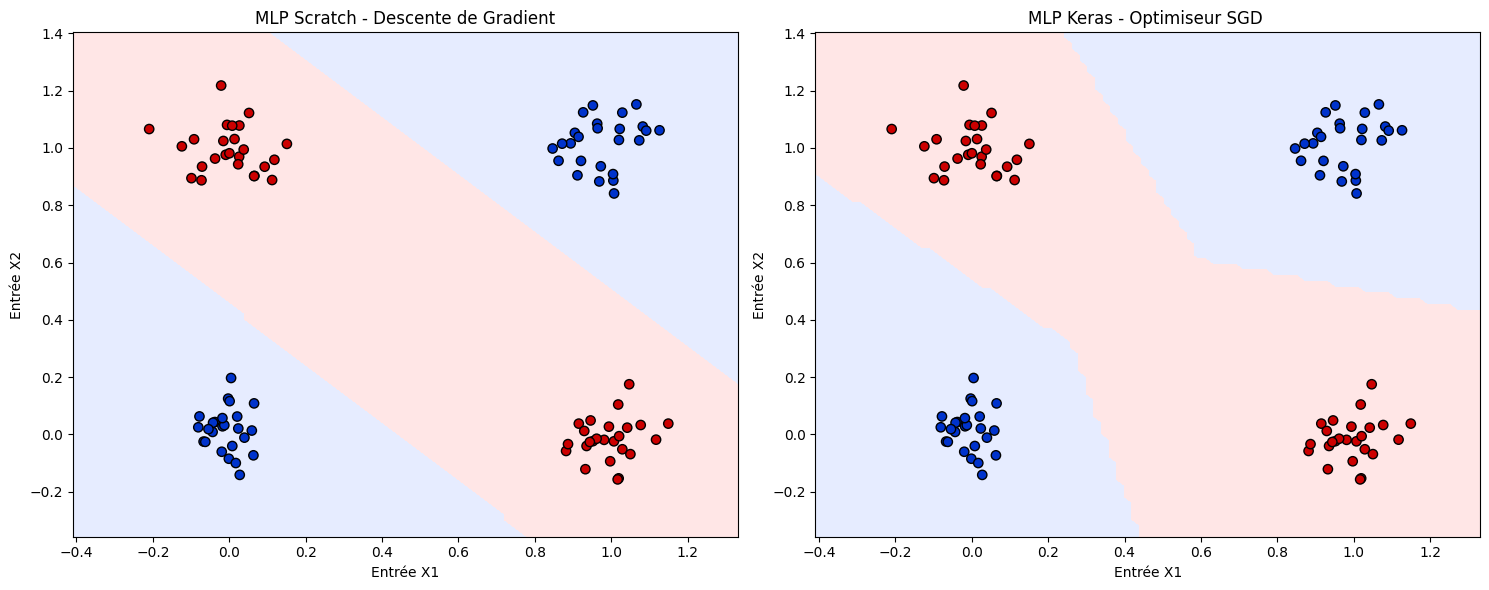

In [15]:
print("COMPARAISON DES PARAMÈTRES APPRIS (SCRATCH VS KERAS)")
W1_scratch = parametres_appris["W1"]  
b1_scratch = parametres_appris["b1"]  
W2_scratch = parametres_appris["W2"]  
b2_scratch = parametres_appris["b2"] 
W1_keras, b1_keras = modele_keras.layers[0].get_weights()
W2_keras, b2_keras = modele_keras.layers[1].get_weights()
print("\n--- COUCHE CACHÉE : POIDS (W1) et BIAIS (b1) ---")
print("W1 , b1 Scratch :\n[", W1_scratch,",",b1_scratch,"]")
print("W1 , b1 Keras:\n[", W1_keras,",",b1_keras,"]")

print("\n--- COUCHE CACHÉE : POIDS (W2) et BIAIS (b2) ---")
print("W2 , b2 Scratch :\n[", W2_scratch.T,",",b2_scratch,"]")
print("W2 , b2 Keras:\n[", W2_keras.T,",",b2_keras,"]")



# --- CONSTRUIRE LA GRILLE DE DÉCISION ---
# Définition de la limite minimale sur l'axe X avec une marge de protection de 0.2
x_min = X_data[:, 0].min() - 0.2
# Définition de la limite maximale sur l'axe X avec une marge de protection de 0.2
x_max = X_data[:, 0].max() + 0.2
# Définition de la limite minimale sur l'axe Y avec une marge de protection de 0.2
y_min = X_data[:, 1].min() - 0.2
# Définition de la limite maximale sur l'axe Y avec une marge de protection de 0.2
y_max = X_data[:, 1].max() + 0.2

# Génération d'un maillage régulier (grille) de points espacés de 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Reconstruction des coordonnées de chaque pixel sous forme de couple (x1, x2)
# .ravel() aplatit les matrices en vecteurs unidimensionnels
# np.c_ regroupe les vecteurs horizontalement pour créer un tableau de coordonnées de pixels
points_grille = np.c_[xx.ravel(), yy.ravel()]

# -- Calcul des zones de décision pour le graphique Scratch --
# On applique la fonction predict_scratch sur tous les points géométriques de la grille
# .reshape() remet les prédictions au format bidimensionnel de la grille pour l'affichage
predictions_grille_scratch = predict_scratch(points_grille, parametres_appris).reshape(xx.shape)

# -- Calcul des zones de décision pour le graphique Keras --
# On applique le modèle Keras sur tous les points géométriques de la grille
# On applique le seuil de décision de 0.5 pour obtenir des classes strictes (0 ou 1)
# .reshape() remet les prédictions au format bidimensionnel de la grille pour l'affichage
predictions_grille_keras = (modele_keras.predict(points_grille) >= 0.5).astype(int).reshape(xx.shape)


# -- CONFIGURATION DU STYLE SIMPLIFIÉ À DEUX COULEURS ---
# Définition des couleurs d'arrière-plan (Bleu pastel pour la classe 0, Rouge pastel pour la classe 1)
couleurs_fond = ['#E6ECFF', '#FFE6E6']
# Définition des couleurs des marqueurs réels (Bleu vif pour la classe 0, Rouge vif pour la classe 1)
couleurs_points = ['#0033CC', '#CC0000']

# Création des cartes de couleurs matplotlib personnalisées à partir de nos listes de couleurs
cmap_fond = plt.cm.colors.ListedColormap(couleurs_fond)
cmap_points = plt.cm.colors.ListedColormap(couleurs_points)


# --- TRACÉ DES GRAPHIQUES PLT ---
# Initialisation de la figure avec une dimension de 15x6 pour l'affichage côte à côte
plt.figure(figsize=(15, 6))

# --- Graphique gauche : Modèle Scratch ---
# Positionnement sur la première case du tracé (1 ligne, 2 colonnes, position 1)
plt.subplot(1, 2, 1)
# Dessin de la surface de décision colorée en arrière-plan selon les prédictions du scratch
plt.contourf(xx, yy, predictions_grille_scratch, cmap=cmap_fond)
# Superposition des points de données d'apprentissage réels avec une bordure noire
plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data.ravel(), cmap=cmap_points, edgecolor='black', s=45)
# Titre du premier graphique affichant l'exactitude atteinte par le code scratch
plt.title(f"MLP Scratch - Descente de Gradient")
# Étiquette de l'axe des abscisses
plt.xlabel("Entrée X1")
# Étiquette de l'axe des ordonnées
plt.ylabel("Entrée X2")

# --- Graphique droit : Modèle Keras ---
# Positionnement sur la deuxième case du tracé (1 ligne, 2 colonnes, position 2)
plt.subplot(1, 2, 2)
# Dessin de la surface de décision colorée en arrière-plan selon les prédictions de Keras
plt.contourf(xx, yy, predictions_grille_keras, cmap=cmap_fond)
# Superposition des points de données d'apprentissage réels avec une bordure noire
plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data.ravel(), cmap=cmap_points, edgecolor='black', s=45)
# Titre du second graphique affichant l'exactitude atteinte par Keras
plt.title(f"MLP Keras - Optimiseur SGD ")
# Étiquette de l'axe des abscisses
plt.xlabel("Entrée X1")
# Étiquette de l'axe des ordonnées
plt.ylabel("Entrée X2")

# Ajustement automatique des espaces entre les sous-graphiques pour éviter les chevauchements
plt.tight_layout()
# Affichage de la figure finale à l'écran
plt.show()